# Pareto Optimization Results Analysis - Wide Dataset

This notebook loads and analyzes Pareto portfolio optimization results for the **Wide Dataset**, providing comprehensive comparisons of efficient frontiers across different solvers.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

# Create artifacts directory for saving plots
artifacts_dir = '../../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Artifacts directory: {artifacts_dir}")

Artifacts directory: ../../artifacts


## Data Loading Functions

In [6]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_pareto_filename(filename):
    """Parse Pareto optimization result filename to extract metadata."""
    # Expected formats:
    # pareto_wide_dwave_cqm_lambda_XX_period_Y.pkl
    # pareto_wide_ga_period_Y.pkl
    # pareto_wide_slsqp_period_Y.pkl
    # pareto_wide_riskfolio_period_Y.pkl
    
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').split('_')
    
    # Extract period (always last part after 'period')
    try:
        period_idx = parts.index('period')
        period = int(parts[period_idx + 1])
    except (ValueError, IndexError):
        return None, None, None, None
    
    # Extract dataset (should be after 'pareto')
    dataset = parts[1] if len(parts) > 1 else None
    
    # Extract lambda if present
    lambda_val = None
    if 'lambda' in parts:
        lambda_idx = parts.index('lambda')
        if lambda_idx + 1 < len(parts):
            lambda_val = int(parts[lambda_idx + 1])
    
    # Extract solver (everything between dataset and lambda/period)
    if 'lambda' in parts:
        lambda_idx = parts.index('lambda')
        solver_parts = parts[2:lambda_idx]
    else:
        solver_parts = parts[2:period_idx]
    
    solver = '_'.join(solver_parts) if solver_parts else None
    
    return dataset, solver, lambda_val, period

def load_all_results(results_dir='../../results/pareto_optimization'):
    """Load all Pareto optimization results from the directory."""
    results = []
    
    # Find all pickle files
    pickle_files = glob.glob(os.path.join(results_dir, '*.pkl'))
    
    print(f"Found {len(pickle_files)} result files")
    
    for file_path in pickle_files:
        # Parse filename
        dataset, solver, lambda_val, period = parse_pareto_filename(file_path)
        
        if dataset is not None and solver is not None:
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Check if this file has nested lambda values (classical solvers)
                # or direct values (D-Wave CQM)
                if isinstance(data, dict) and all(isinstance(k, (int, float)) for k in data.keys()):
                    # Classical solvers: nested structure with lambda values as keys
                    for lambda_key, lambda_data in data.items():
                        if isinstance(lambda_data, dict):
                            final_return = lambda_data.get('portfolio_return', None)
                            portfolio_risk = lambda_data.get('portfolio_risk', None)
                            execution_time = lambda_data.get('execution_time', 0)
                            
                            results.append({
                                'filename': os.path.basename(file_path),
                                'dataset': dataset,
                                'period': period,
                                'solver': solver,
                                'lambda': lambda_key,
                                'final_return': final_return,
                                'portfolio_risk': portfolio_risk,
                                'execution_time': execution_time,
                                'data': lambda_data
                            })
                else:
                    # D-Wave CQM: direct structure
                    final_return = data.get('portfolio_return', None)
                    portfolio_risk = data.get('portfolio_risk', None)
                    execution_time = data.get('execution_time', 0)
                    
                    results.append({
                        'filename': os.path.basename(file_path),
                        'dataset': dataset,
                        'period': period,
                        'solver': solver,
                        'lambda': lambda_val,
                        'final_return': final_return,
                        'portfolio_risk': portfolio_risk,
                        'execution_time': execution_time,
                        'data': data
                    })
    
    return results

# Load all results
print("Loading all Pareto optimization results...")
all_results = load_all_results()
print(f"Loaded {len(all_results)} successful results")

Loading all Pareto optimization results...
Found 41 result files
Loaded 341 successful results


In [7]:
# Create summary DataFrame and filter for wide dataset only
df_results = pd.DataFrame(all_results)

# Filter for wide dataset only
df_results = df_results[df_results['dataset'] == 'wide'].copy()

# Display overview
print("=" * 80)
print("PARETO OPTIMIZATION RESULTS - WIDE DATASET")
print("=" * 80)

print(f"\nTotal results loaded: {len(df_results)}")
print(f"Solvers: {sorted(df_results['solver'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")

# Summary by solver
print("\nResults count by solver:")
print(df_results['solver'].value_counts().sort_index())

# Check lambda values for D-Wave CQM
dwave_data = df_results[df_results['solver'] == 'dwave_cqm']
if len(dwave_data) > 0:
    print(f"\nD-Wave CQM Lambda values: {sorted(dwave_data['lambda'].unique())}")

# Map solver codes to readable names
solver_names = {
    'ga': 'Genetic Algorithm',
    'slsqp': 'Scipy SLSQP',
    'riskfolio': 'Riskfolio',
    'dwave_cqm': 'D-Wave CQM'
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))
df_results['dataset_name'] = 'Wide Dataset'

# Create df_wide alias for compatibility with existing code
df_wide = df_results.copy()


PARETO OPTIMIZATION RESULTS - WIDE DATASET

Total results loaded: 341
Solvers: ['dwave_cqm', 'ga', 'riskfolio', 'slsqp']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Results count by solver:
solver
dwave_cqm     11
ga           110
riskfolio    110
slsqp        110
Name: count, dtype: int64

D-Wave CQM Lambda values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]



AGGREGATING DATA - AVERAGING ACROSS PERIODS FOR EACH LAMBDA

dwave_cqm:
  Lambda values: 11
  Periods averaged: 1

ga:
  Lambda values: 11
  Periods averaged: 10

riskfolio:
  Lambda values: 11
  Periods averaged: 10

slsqp:
  Lambda values: 11
  Periods averaged: 10

FILTERING OUT LAMBDA = 0 FROM D-WAVE CQM (OUTLIER)
D-Wave CQM points before filtering: 11
D-Wave CQM points after filtering: 10
Removed 1 outlier point(s)

Total aggregated points: 43
Points per solver: {'D-Wave CQM': 10, 'Genetic Algorithm': 11, 'Riskfolio': 11, 'Scipy SLSQP': 11}

INDIVIDUAL EFFICIENT FRONTIERS - BY SOLVER (AVERAGED ACROSS PERIODS)

D-Wave CQM: 10 lambda values
  Pareto optimal points: 3 (lambdas: ['1.0', '4.0', '9.0'])
Saved: pareto_efficient_frontier_d-wave_cqm.png


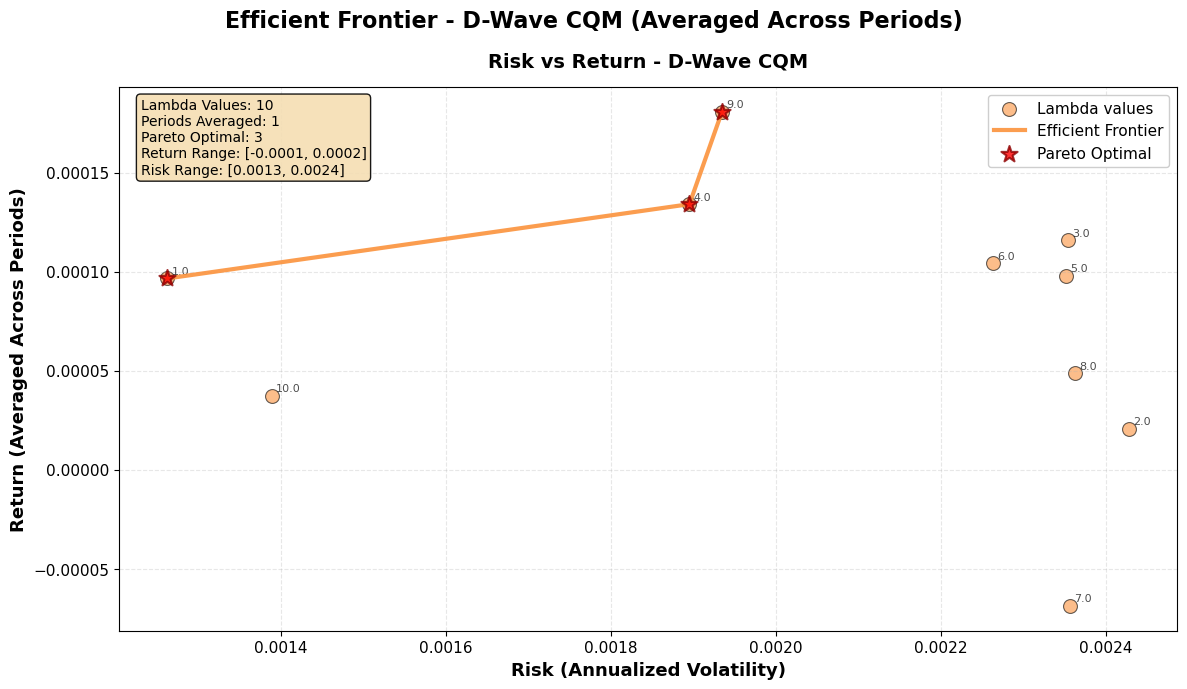


Genetic Algorithm: 11 lambda values
  Pareto optimal points: 2 (lambdas: ['0.7', '0.2'])
Saved: pareto_efficient_frontier_genetic_algorithm.png


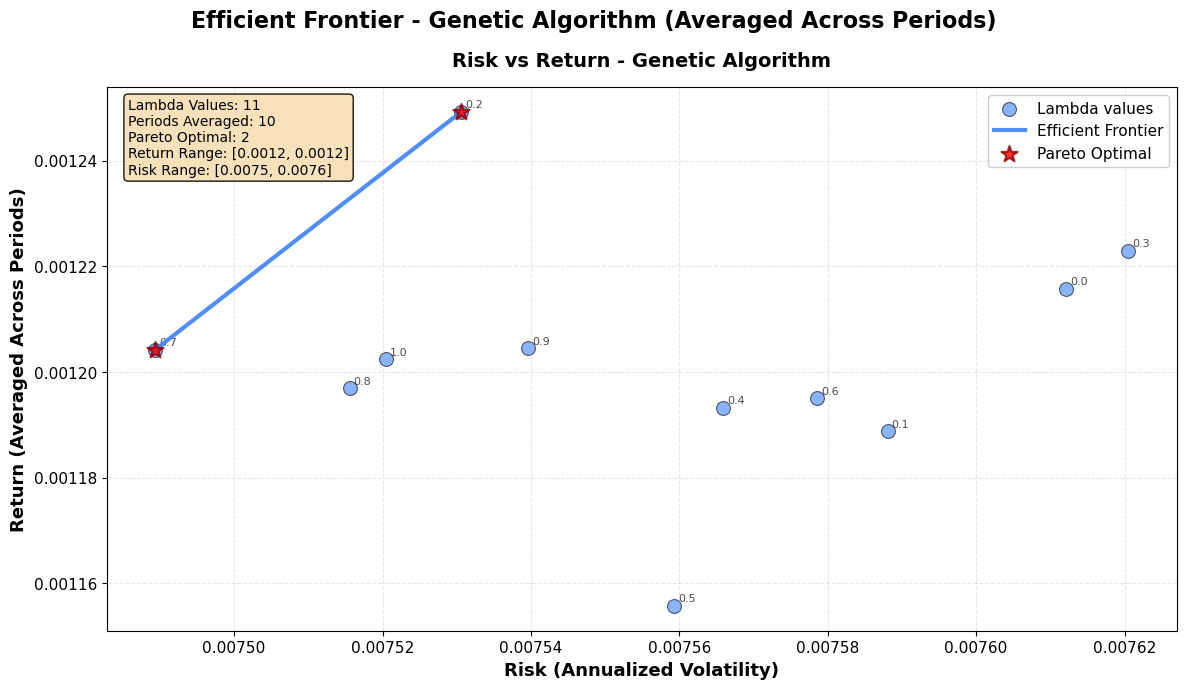


Riskfolio: 11 lambda values
  Pareto optimal points: 11 (lambdas: ['1.0', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0.0'])
Saved: pareto_efficient_frontier_riskfolio.png


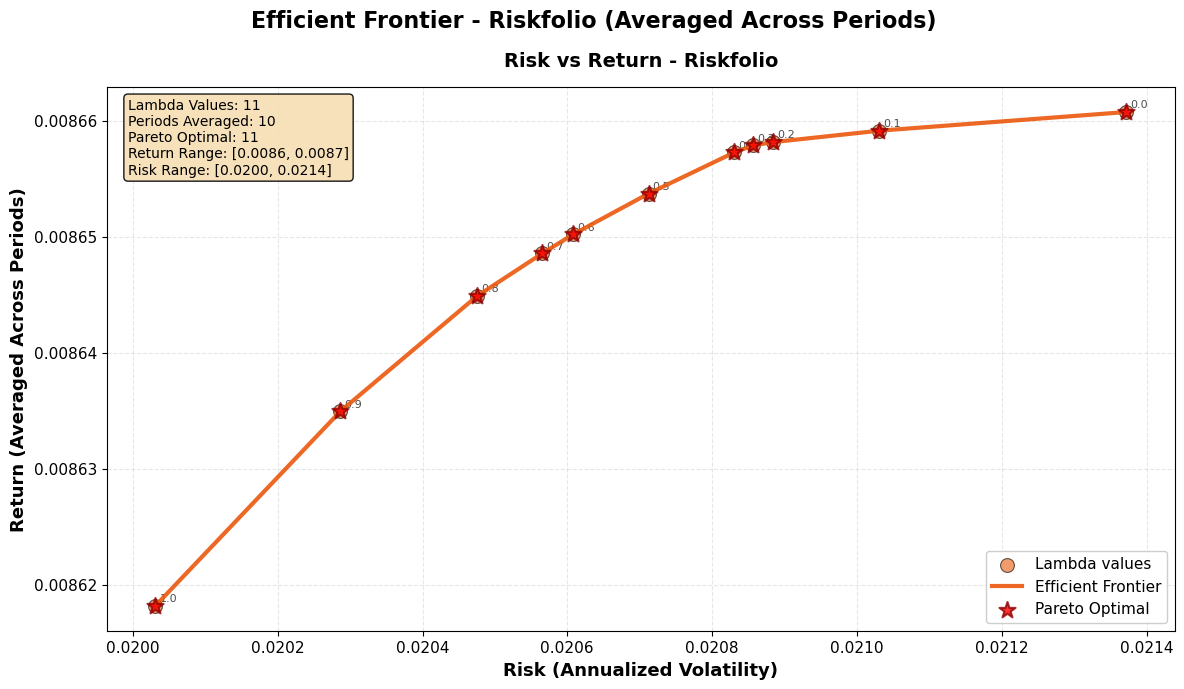


Scipy SLSQP: 11 lambda values
  Pareto optimal points: 11 (lambdas: ['1.0', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0.0'])
Saved: pareto_efficient_frontier_scipy_slsqp.png


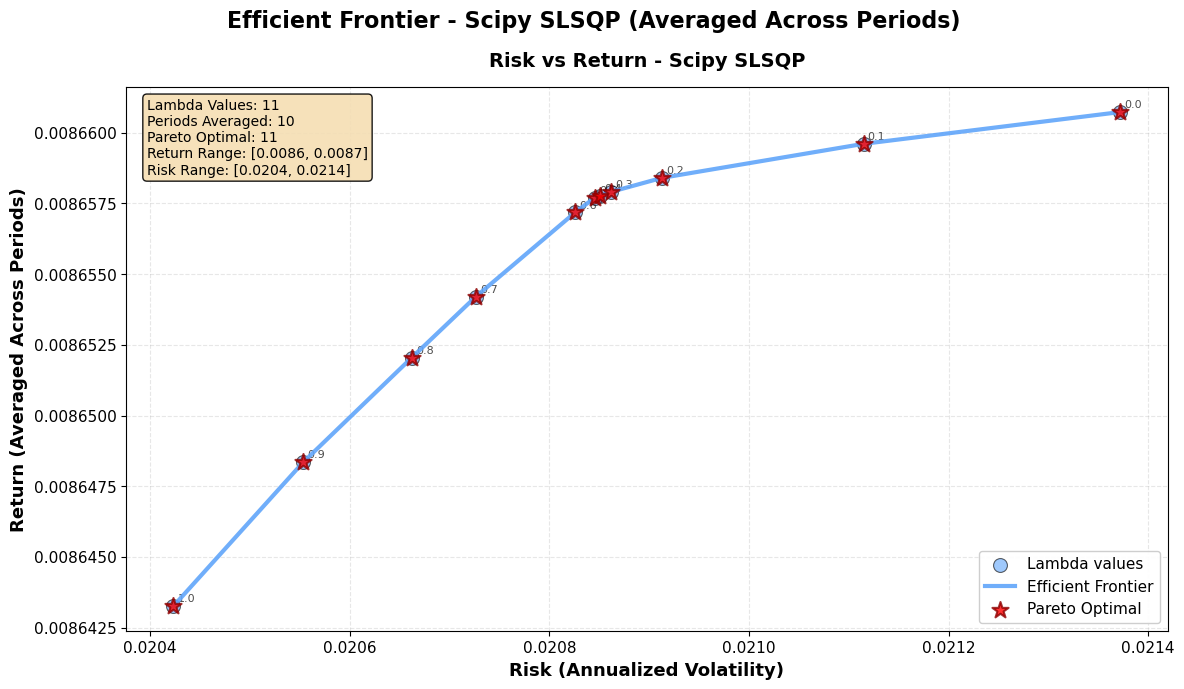


4 individual plots created

COMBINED EFFICIENT FRONTIER - ALL SOLVERS (AVERAGED ACROSS PERIODS)
Saved: pareto_efficient_frontier_combined.png


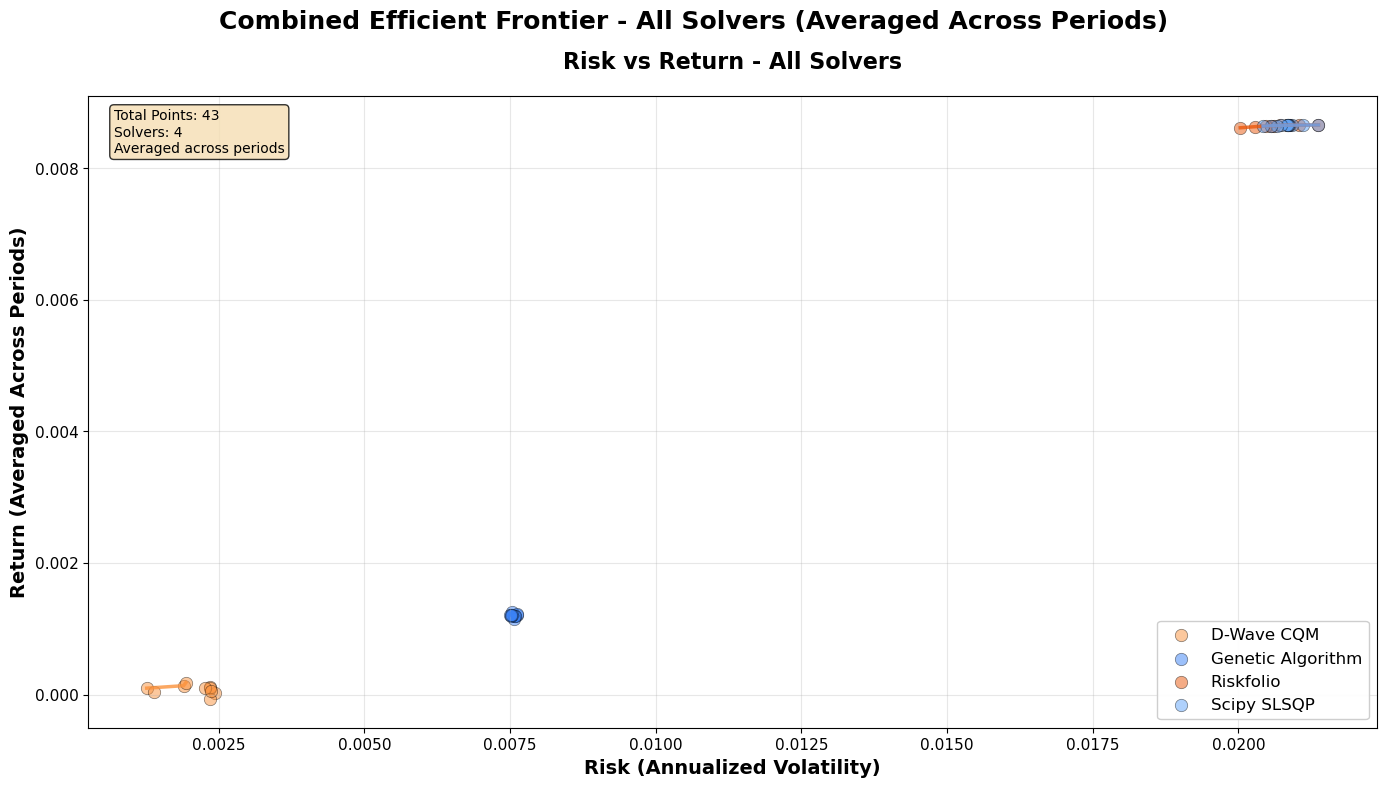

In [8]:
# Define colors for each solver
solver_colors = {
    'Genetic Algorithm': '#3B82F6',   # Medium blue
    'Scipy SLSQP': '#60A5FA',         # Light blue
    'Riskfolio': '#EA580C',            # Deep orange
    'D-Wave CQM': '#FB923C'            # Light orange
}

# Aggregate data: Average returns and risk across periods for each lambda value
print("\n" + "=" * 100)
print("AGGREGATING DATA - AVERAGING ACROSS PERIODS FOR EACH LAMBDA")
print("=" * 100)

aggregated_results = []
for solver_name in sorted(df_wide['solver'].unique()):
    solver_data = df_wide[df_wide['solver'] == solver_name]
    
    # Group by lambda and average across periods
    grouped = solver_data.groupby('lambda').agg({
        'portfolio_risk': 'mean',
        'final_return': 'mean',
        'execution_time': 'mean',
        'period': 'count'  # Count how many periods contributed
    }).reset_index()
    
    grouped['solver'] = solver_name
    aggregated_results.append(grouped)
    
    print(f"\n{solver_name}:")
    print(f"  Lambda values: {len(grouped)}")
    print(f"  Periods averaged: {grouped['period'].iloc[0] if len(grouped) > 0 else 0}")

# Combine aggregated results
df_aggregated = pd.concat(aggregated_results, ignore_index=True)

# Map solver names
solver_names = {
    'ga': 'Genetic Algorithm',
    'slsqp': 'Scipy SLSQP',
    'riskfolio': 'Riskfolio',
    'dwave_cqm': 'D-Wave CQM'
}
df_aggregated['solver_name'] = df_aggregated['solver'].map(lambda x: solver_names.get(x, x))

# Filter out lambda = 0 from D-Wave CQM (outlier)
print("\n" + "=" * 100)
print("FILTERING OUT LAMBDA = 0 FROM D-WAVE CQM (OUTLIER)")
print("=" * 100)
before_count = len(df_aggregated[df_aggregated['solver'] == 'dwave_cqm'])
df_aggregated = df_aggregated[~((df_aggregated['solver'] == 'dwave_cqm') & (df_aggregated['lambda'] == 0))]
after_count = len(df_aggregated[df_aggregated['solver'] == 'dwave_cqm'])
print(f"D-Wave CQM points before filtering: {before_count}")
print(f"D-Wave CQM points after filtering: {after_count}")
print(f"Removed {before_count - after_count} outlier point(s)")

print(f"\nTotal aggregated points: {len(df_aggregated)}")
print(f"Points per solver: {df_aggregated.groupby('solver_name').size().to_dict()}")

# Individual Efficient Frontiers - One plot per solver
print("\n" + "=" * 100)
print("INDIVIDUAL EFFICIENT FRONTIERS - BY SOLVER (AVERAGED ACROSS PERIODS)")
print("=" * 100)

n_plots_created = 0
for solver_name in sorted(df_aggregated['solver_name'].unique()):
    solver_data = df_aggregated[df_aggregated['solver_name'] == solver_name]

    # Filter valid data points
    valid_data = solver_data[
        (solver_data['final_return'].notna()) &
        (solver_data['portfolio_risk'].notna())
    ]

    print(f"\n{solver_name}: {len(valid_data)} lambda values")

    if len(valid_data) > 0:
        n_plots_created += 1
        
        # Create individual plot for this solver
        fig, ax = plt.subplots(1, 1, figsize=(12, 7))
        fig.suptitle(f'Efficient Frontier - {solver_name} (Averaged Across Periods)',
                     fontsize=16, fontweight='bold')

        risks = valid_data['portfolio_risk'].values
        returns = valid_data['final_return'].values
        lambdas = valid_data['lambda'].values

        color = solver_colors.get(solver_name, '#000000')

        # Plot all points
        scatter = ax.scatter(risks, returns, color=color, s=100, alpha=0.6,
                  edgecolors='black', linewidth=0.8, label='Lambda values')

        # Add lambda labels to points
        for i, (r, ret, lam) in enumerate(zip(risks, returns, lambdas)):
            ax.annotate(f'{lam:.1f}', (r, ret), fontsize=8, alpha=0.7,
                       xytext=(3, 3), textcoords='offset points')

        # Compute and plot the Pareto frontier (convex hull)
        # Sort points by risk
        sorted_indices = np.argsort(risks)
        sorted_risks = risks[sorted_indices]
        sorted_returns = returns[sorted_indices]
        sorted_lambdas = lambdas[sorted_indices]

        # Find Pareto optimal points (non-dominated)
        pareto_risks = []
        pareto_returns = []
        pareto_lambdas = []
        max_return = -np.inf

        for r, ret, lam in zip(sorted_risks, sorted_returns, sorted_lambdas):
            if ret > max_return:
                pareto_risks.append(r)
                pareto_returns.append(ret)
                pareto_lambdas.append(lam)
                max_return = ret

        print(f"  Pareto optimal points: {len(pareto_risks)} (lambdas: {[f'{l:.1f}' for l in pareto_lambdas]})")

        # Plot Pareto frontier line
        if len(pareto_risks) > 1:
            ax.plot(pareto_risks, pareto_returns, color=color, linewidth=3,
                   alpha=0.9, linestyle='-', label='Efficient Frontier', zorder=5)

            # Mark Pareto optimal points
            ax.scatter(pareto_risks, pareto_returns, color='red', s=150,
                      alpha=0.8, marker='*', edgecolors='darkred', linewidth=1.5,
                      label='Pareto Optimal', zorder=6)
        elif len(pareto_risks) == 1:
            # If only one point, just mark it
            ax.scatter(pareto_risks, pareto_returns, color='red', s=150,
                      alpha=0.8, marker='*', edgecolors='darkred', linewidth=1.5,
                      label='Pareto Optimal', zorder=6)

        # Format the plot
        ax.set_xlabel('Risk (Annualized Volatility)', fontweight='bold', fontsize=13)
        ax.set_ylabel('Return (Averaged Across Periods)', fontweight='bold', fontsize=13)
        ax.set_title(f'Risk vs Return - {solver_name}', fontweight='bold', fontsize=14, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=11, framealpha=0.95)

        # Add statistics text box
        n_periods = valid_data['period'].iloc[0] if len(valid_data) > 0 else 0
        stats_text = (f'Lambda Values: {len(valid_data)}\n'
                     f'Periods Averaged: {n_periods}\n'
                     f'Pareto Optimal: {len(pareto_risks)}\n'
                     f'Return Range: [{returns.min():.4f}, {returns.max():.4f}]\n'
                     f'Risk Range: [{risks.min():.4f}, {risks.max():.4f}]')
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

        plt.tight_layout()
        
        # Save the figure
        safe_solver_name = solver_name.lower().replace(' ', '_')
        filename = f'pareto_efficient_frontier_{safe_solver_name}.png'
        plt.savefig(os.path.join(artifacts_dir, filename), dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        plt.show()
    else:
        print(f"  WARNING: No valid data points found for {solver_name}")

print(f"\n{n_plots_created} individual plots created")

# Combined Efficient Frontier - All Solvers Comparison
print("\n" + "=" * 100)
print("COMBINED EFFICIENT FRONTIER - ALL SOLVERS (AVERAGED ACROSS PERIODS)")
print("=" * 100)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
fig.suptitle('Combined Efficient Frontier - All Solvers (Averaged Across Periods)',
             fontsize=18, fontweight='bold')

# Plot each solver's points
for solver_name in sorted(df_aggregated['solver_name'].unique()):
    solver_data = df_aggregated[df_aggregated['solver_name'] == solver_name]

    # Filter valid data points
    valid_data = solver_data[
        (solver_data['final_return'].notna()) &
        (solver_data['portfolio_risk'].notna())
    ]

    if len(valid_data) > 0:
        risks = valid_data['portfolio_risk'].values
        returns = valid_data['final_return'].values

        color = solver_colors.get(solver_name, '#000000')

        # Plot all points
        ax.scatter(risks, returns, color=color, s=80, alpha=0.5,
                  label=solver_name, edgecolors='black', linewidth=0.5)

        # Compute and plot the Pareto frontier (convex hull)
        # Sort points by risk
        sorted_indices = np.argsort(risks)
        sorted_risks = risks[sorted_indices]
        sorted_returns = returns[sorted_indices]

        # Find Pareto optimal points (non-dominated)
        pareto_risks = []
        pareto_returns = []
        max_return = -np.inf

        for r, ret in zip(sorted_risks, sorted_returns):
            if ret > max_return:
                pareto_risks.append(r)
                pareto_returns.append(ret)
                max_return = ret

        # Plot Pareto frontier line
        if len(pareto_risks) > 1:
            ax.plot(pareto_risks, pareto_returns, color=color, linewidth=2.5,
                   alpha=0.8, linestyle='-', zorder=5)

# Format the plot
ax.set_xlabel('Risk (Annualized Volatility)', fontweight='bold', fontsize=14)
ax.set_ylabel('Return (Averaged Across Periods)', fontweight='bold', fontsize=14)
ax.set_title('Risk vs Return - All Solvers', fontweight='bold', fontsize=16, pad=20)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.95)

# Add text box with statistics
n_points = len(df_aggregated[df_aggregated['final_return'].notna()])
n_solvers = len(df_aggregated['solver_name'].unique())
stats_text = f'Total Points: {n_points}\nSolvers: {n_solvers}\nAveraged across periods'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'pareto_efficient_frontier_combined.png'), dpi=300, bbox_inches='tight')
print("Saved: pareto_efficient_frontier_combined.png")
plt.show()